In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("/Users/nurilasalamat/Documents/ml/practice3/statlog+german+credit+data/german.data", sep =r"\s+")
df.shape #number of rows and columns


(999, 21)

In [ ]:
df.head() #5 first rows of dataset


,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1.1
0,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
1,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
2,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
3,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
4,A14,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1


In [15]:
#target variable distribution

y = df.iloc[:, -1]  # Assuming the last column is the target variable
y.value_counts()

y_clean = y.map({1 : "Good", 2: "Bad"})


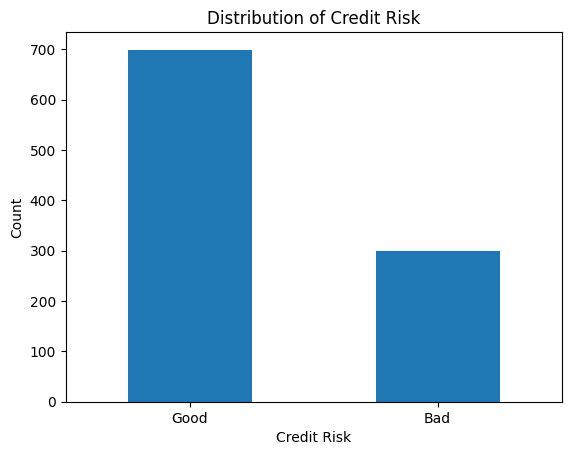

In [16]:
y_clean.value_counts().plot(kind = "bar")
plt.xlabel("Credit Risk")
plt.ylabel("Count")
plt.title("Distribution of Credit Risk")
plt.xticks(rotation = 0)
plt.show()

What is a default/bad risk in bank context?
In a banking context, a default or bad credit risk refers to a borrower who is likely to fail to repay their loan according to the agreed terms. This typically means missing multiple payments or being unable to cover the debt within the scheduled time period. From the bank’s perspective, such borrowers represent a higher probability of financial loss because the expected interest and principal may not be fully recovered. A bad risk classification is usually based on factors like low income stability, high existing debt, poor credit history, or inconsistent repayment behavior. Banks use this assessment to decide whether to approve a loan, set higher interest rates, or require collateral. Essentially, labeling someone as a default risk helps the bank manage uncertainty and reduce potential losses.

Mistakes matter because each type hits differently in real life, especially in credit risk. A false negative (predicting someone is safe when they’re actually risky) can cost the bank money since they may default on the loan — that’s the expensive mistake. A false positive (flagging a good borrower as risky) means rejecting someone who would’ve paid back, so the bank loses potential profit and the customer gets unfair treatment. Neither error is harmless — one hurts finances directly, the other hurts business trust and growth. That’s why models aren’t just about accuracy; balancing these errors is kinda the whole game.

In [18]:
#Check missing values
df.isnull().sum()

A11     0
6       0
A34     0
A43     0
1169    0
A65     0
A75     0
4       0
A93     0
A101    0
4.1     0
A121    0
67      0
A143    0
A152    0
2       0
A173    0
1       0
A192    0
A201    0
1.1     0
dtype: int64

In [23]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(numeric_cols)

Index(['6', '1169', '4', '4.1', '67', '2', '1', '1.1'], dtype='str')


In [24]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['A11', 'A34', 'A43', 'A65', 'A75', 'A93', 'A101', 'A121', 'A143',
       'A152', 'A173', 'A192', 'A201'],
      dtype='str')


/var/folders/cj/pyg3106x49q_d54nbw4ww5k80000gn/T/ipykernel_4057/4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [27]:
#correlation matrix
numeric_df = df[numeric_cols]
corr_matrix = numeric_df.corr()
print(corr_matrix)

             6      1169         4       4.1        67         2         1  \
6     1.000000  0.624714  0.075976  0.035410 -0.032863 -0.010025 -0.024385   
1169  0.624714  1.000000 -0.270820  0.029732  0.034924  0.021578  0.016829   
4     0.075976 -0.270820  1.000000  0.048387  0.055961  0.020744 -0.070850   
4.1   0.035410  0.029732  0.048387  1.000000  0.264680  0.088644  0.043120   
67   -0.032863  0.034924  0.055961  0.264680  1.000000  0.147051  0.119858   
2    -0.010025  0.021578  0.020744  0.088644  0.147051  1.000000  0.110175   
1    -0.024385  0.016829 -0.070850  0.043120  0.119858  0.110175  1.000000   
1.1   0.214326  0.154326  0.073052  0.003656 -0.089678 -0.045093 -0.003297   

           1.1  
6     0.214326  
1169  0.154326  
4     0.073052  
4.1   0.003656  
67   -0.089678  
2    -0.045093  
1    -0.003297  
1.1   1.000000  


In [32]:
corr_with_target = corr_matrix.iloc[:, -1]

top_corr = (
    corr_with_target
    .drop(corr_with_target.index[-1])
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print(top_corr)

6       0.214326
1169    0.154326
67      0.089678
Name: 1.1, dtype: float64


In [33]:
#Training, test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=df.columns[-1])
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [36]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(include="object").columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

/var/folders/cj/pyg3106x49q_d54nbw4ww5k80000gn/T/ipykernel_4057/1408547508.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score, recall_score, f1_score)

logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

tree_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

knn_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsClassifier())
])

models = {
    "Logistic Regression": logreg_pipe,
    "Decision Tree": tree_pipe,
    "kNN": knn_pipe
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [39]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label=2))
    print("Recall:", recall_score(y_test, y_pred, pos_label=2))
    print("F1:", f1_score(y_test, y_pred, pos_label=2))


Logistic Regression
Accuracy: 0.78
Confusion matrix:
 [[121  19]
 [ 25  35]]
Precision: 0.6481481481481481
Recall: 0.5833333333333334
F1: 0.6140350877192983

Decision Tree
Accuracy: 0.655
Confusion matrix:
 [[98 42]
 [27 33]]
Precision: 0.44
Recall: 0.55
F1: 0.4888888888888889

kNN
Accuracy: 0.75
Confusion matrix:
 [[125  15]
 [ 35  25]]
Precision: 0.625
Recall: 0.4166666666666667
F1: 0.5


In credit risk assessment, approving a bad client (a false negative) is generally considered worse than rejecting a good client (a false positive). When a bank approves a risky borrower who later defaults, it can lead to direct financial losses, including unpaid principal and interest, as well as additional recovery costs. In contrast, rejecting a good borrower mainly results in lost business opportunities and potential customer dissatisfaction, but not an immediate monetary loss. Because of this, financial institutions typically prioritize minimizing false negatives to reduce the risk of default and protect overall financial stability.

In [40]:
y_prob = logreg_pipe.predict_proba(X_test)[:, 1]

In [43]:
import numpy as np

thresholds = [0.65, 0.50, 0.35]

for t in thresholds:
    y_pred = np.where(y_prob >= t, 2, 1)

    print(f"\nThreshold = {t}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label=2))
    print("Recall:", recall_score(y_test, y_pred, pos_label=2))
    print("F1:", f1_score(y_test, y_pred, pos_label=2))


Threshold = 0.65
Confusion matrix:
 [[133   7]
 [ 37  23]]
Precision: 0.7666666666666667
Recall: 0.38333333333333336
F1: 0.5111111111111111

Threshold = 0.5
Confusion matrix:
 [[121  19]
 [ 25  35]]
Precision: 0.6481481481481481
Recall: 0.5833333333333334
F1: 0.6140350877192983

Threshold = 0.35
Confusion matrix:
 [[102  38]
 [ 14  46]]
Precision: 0.5476190476190477
Recall: 0.7666666666666667
F1: 0.6388888888888888


Lowering the classification threshold increases the number of rejected clients because more applicants are classified as risky even with moderate probabilities of default. A lower threshold, such as 0.35, reduces the number of bad clients approved since the model becomes stricter and flags more potentially risky borrowers. However, this also increases the number of good clients rejected, meaning some reliable borrowers may be denied credit unnecessarily. Among the compared values, the lower threshold generally minimizes financial risk by reducing false negatives, while higher thresholds like 0.65 are less strict but may allow more risky clients to be approved. If I were the Head of Risk, I would recommend a lower threshold because preventing loan defaults usually outweighs the cost of rejecting some creditworthy customers, helping protect the bank’s financial stability.

In [45]:
zones = np.where(
    y_prob < 0.20, "Auto-approve",
    np.where(y_prob <= 0.50, "Manual review", "Auto-reject")
)
zone_counts = pd.Series(zones).value_counts()
print(zone_counts)

Auto-approve     81
Manual review    65
Auto-reject      54
Name: count, dtype: int64


Using three decision zones helps balance automation and risk management in credit approval. Applications with very low predicted risk can be automatically approved, reducing manual workload and speeding up processing. High-risk applications can be automatically rejected, which helps prevent potential financial losses. Cases with moderate risk are sent for manual review, allowing human experts to make more careful decisions where the model is uncertain. This approach improves efficiency while maintaining better control over credit risk.

The dataset analyzes credit risk by predicting whether a loan applicant is likely to default based on financial and demographic attributes. The main goal was to build machine learning models to classify applicants into good or bad credit risk categories and minimize financial losses for the bank. Among the tested models, logistic regression performed best due to its balanced recall and interpretability. The key evaluation metric was recall for the bad-credit class, since failing to detect risky clients can lead to financial loss. A lower probability threshold was recommended to reduce defaults, and a three-zone decision system (auto-approve, manual review, auto-reject) helps balance efficiency with risk control.

In [46]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall_bad": recall_score(y_test, y_pred, pos_label=2),
        "F1": f1_score(y_test, y_pred, pos_label=2),
        "Comment": "Good balance"  
    })

table = pd.DataFrame(results)
print(table)

                 Model  Accuracy  Recall_bad        F1       Comment
0  Logistic Regression     0.780    0.583333  0.614035  Good balance
1        Decision Tree     0.655    0.550000  0.488889  Good balance
2                  kNN     0.750    0.416667  0.500000  Good balance


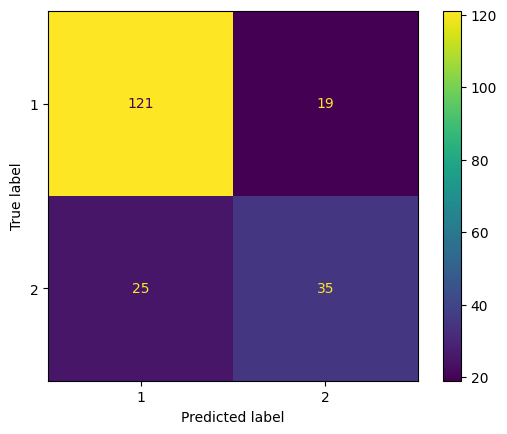

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

model = logreg_pipe  
y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [48]:
sample = X_test.iloc[:3]
probs = logreg_pipe.predict_proba(sample)[:, 1]
zones = ["Approve" if p < 0.2 else
         "Review" if p <= 0.5 else
         "Reject"
         for p in probs]
for i, p in enumerate(probs):
    print(f"Applicant {i+1}")
    print("Probability:", round(p, 3))
    print("Decision:", zones[i])

Applicant 1
Probability: 0.603
Decision: Reject
Applicant 2
Probability: 0.142
Decision: Approve
Applicant 3
Probability: 0.078
Decision: Approve


Approve:
This applicant shows a very low predicted probability of default, indicating stable financial characteristics and low risk.
Review:
The model shows moderate risk; additional manual assessment is recommended before final approval.
Reject:
The high predicted probability suggests significant default risk, making loan approval financially unsafe.